# Assignment 3: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?

A model is 'linear' when the prediction is built on a weighted sum of the features. 'Linear' refers to being linear in coefficients, not necessarily in in the inputs. This means each feature is multiplied by a coefficient to give it a weight. Everything is then added together. There is not multiplying coefficients together and there are no coefficients in non-linear functions. 

2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)

A dummy variable represents the membership in a category (usually 0 or 1). When the dummy is 0, the prediction is simply the intercept. When the dummy is 1, the prediction changes by the dummy coefficient. The coefficient tells us how much the outcome changes compared to the baseline category. 

3. Can linear regression be used for classification? Explain why, or why not.

Yes, it can be used but it is not always the best idea. Linear regression models predict continuous values, but classification needs categories. The thing is, predictions can go beyond 0 and 1, and it doesn't model probabilities properly. It is also sensitive to outliers, and assumes relationships that classification does not follow. Instead you can classify by predicting a number or choosing a cutoff (like 0.5), but this is often unstable and inaccurate. In conclusion, linear regression can classify, but logistic regression is better. 

4. What are signs that your linear model is over-fitting?

Some signs that your model is over-fitting are very-low training error, high test error, large coefficients, and too many features. Very low training error means your model fits training data very well, likely too well. High test error means your performance drops on new data. Large coefficients means weights become very large to fit noise. Over-fitting means great training performance but poor generalization. 

5. Clearly explain multi-colinearity using the two-stage least squares technique.

Multi-colinearity happens when two or more predictors contain the same information. Stage one includes prediction of one correlated variable, using the other variables, and, extracting the part that is not correlated. Stage two includes using the 'clean' version in the regression. So, multi-colinearity means predictors overlap in information, and two-stage least squares isolates independent variation. 

6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?

One way to incorporate nonlinear relationships is through polynomial features, specifically by adding squared and cubic terms. Another way is through transformations using; log(x), sqrt(x), and exp(x). Another way is through interaction terms, by multiplying features together. For example, age x income and height x weight. Also, using different slopes in different regions like in piecewise models is effective. 

7. What is the interpretation of the slope coefficient in a linear regression?

The slope coefficient tells you how much the prediction changes when the feature increases by one unit, while holding everything else constant. It is essential that you only increase the feature by one unit, view a change in predicted outcome, and that all other variables are fixed. 

8. Compare the train/test split and $k$-fold cross validation.

When using train/test split, you split the data once, train on one part, and test on the other. This method is fast but often noisy depending on the split. When using k-fold cross validation, we split into k groups and train k times. Each group becomes the test once. Using k-fold uses all data for training and testing. It is also more stable and less dependant on a good split. However, some disadvantages are that this method is slower and there is more computation. 

9.  How is the $k$ in $k$-fold cross validation typically selected?

The k value in k-fold is typically a small number like 5 or 10. These small values of k are more common because they are faster and produce higher bias. While large k-values are slower and produce low bias and high variance. 5-fold is the most common as it balances between speed and reliability

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regress price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf

from sklearn.model_selection import KFold, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer

In [3]:
df = pd.read_csv("./data/Q1_clean.csv")
df.head()

,Price,Review Scores Rating,Neighbourhood,Property Type,Room Type
0,549,96.0,Manhattan,Apartment,Private room
1,149,100.0,Brooklyn,Apartment,Entire home/apt
2,250,100.0,Manhattan,Apartment,Entire home/apt
3,90,94.0,Brooklyn,Apartment,Private room
4,270,90.0,Manhattan,Apartment,Entire home/apt


In [4]:
df = df.rename(columns={
    "Price": "price",
    "Review Scores Rating": "review_score_rating",
    "Neighbourhood": "neighbourhood"
})

In [12]:
df.columns = df.columns.str.strip()

df = df.rename(columns={
    "Price": "price",
    "Review Scores Rating": "review_score_rating",
    "Neighbourhood": "neighbourhood"
})

In [13]:
df = df.dropna(subset=["price", "review_score_rating", "neighbourhood"]).copy()

In [14]:
df["log_price"] = np.log(df["price"])

In [15]:
df.head()

,price,review_score_rating,neighbourhood,Property Type,Room Type,log_price
0,549,96.0,Manhattan,Apartment,Private room,6.308098
1,149,100.0,Brooklyn,Apartment,Entire home/apt,5.003946
2,250,100.0,Manhattan,Apartment,Entire home/apt,5.521461
3,90,94.0,Brooklyn,Apartment,Private room,4.499810
4,270,90.0,Manhattan,Apartment,Entire home/apt,5.598422


QUESTION 1

In [16]:
group_means = (
    df.groupby("neighbourhood")[["price", "review_score_rating"]]
      .mean()
      .sort_values("price", ascending=False)
)

print(group_means)

                    price  review_score_rating
neighbourhood                                 
Manhattan      183.664286            91.801496
Staten Island  146.166667            90.843750
Brooklyn       127.747378            92.363497
Queens          96.857233            91.549057
Bronx           75.276498            91.654378


In [17]:
most_expensive = group_means["price"].idxmax()
print("Most expensive neighbourhood on average:", most_expensive)

Most expensive neighbourhood on average: Manhattan


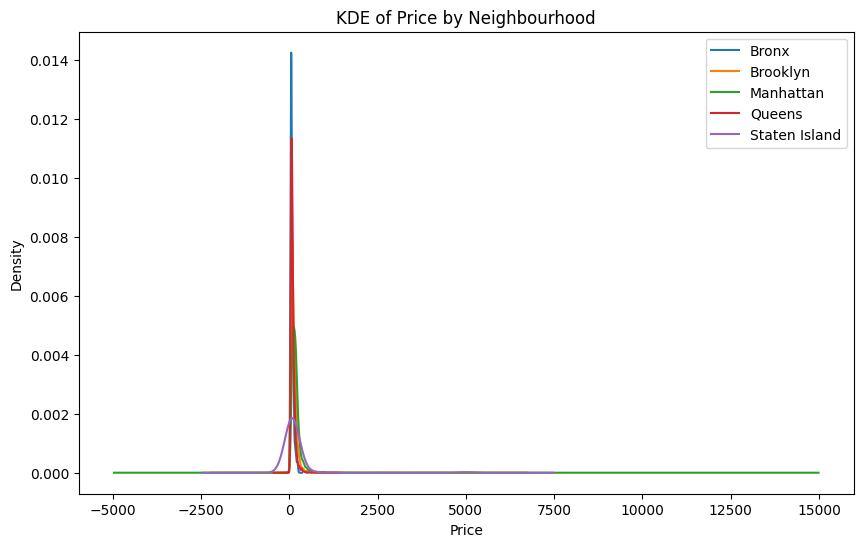

In [18]:
plt.figure(figsize=(10, 6))

for n in sorted(df["neighbourhood"].unique()):
    df.loc[df["neighbourhood"] == n, "price"].plot(
        kind="kde",
        label=n
    )

plt.xlabel("Price")
plt.title("KDE of Price by Neighbourhood")
plt.legend()
plt.show()

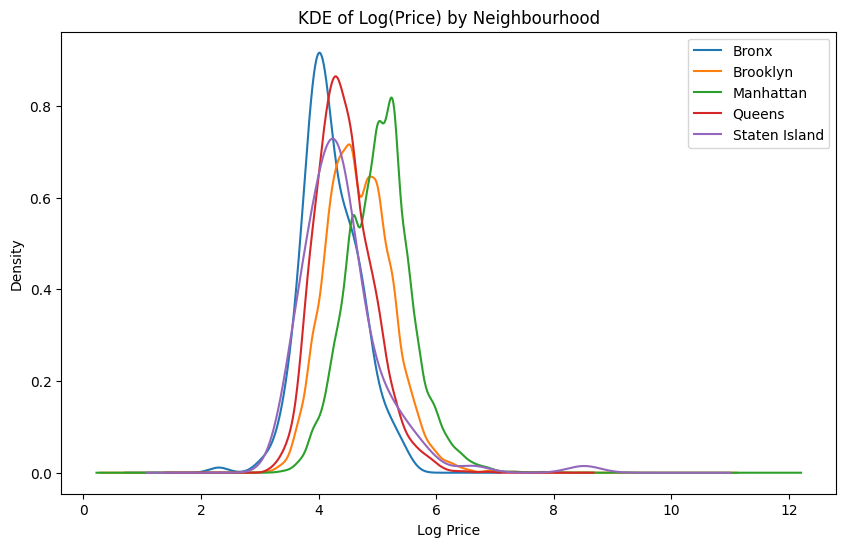

In [19]:
plt.figure(figsize=(10, 6))

for n in sorted(df["neighbourhood"].unique()):
    df.loc[df["neighbourhood"] == n, "log_price"].plot(
        kind="kde",
        label=n
    )

plt.xlabel("Log Price")
plt.title("KDE of Log(Price) by Neighbourhood")
plt.legend()
plt.show()

QUESTION 2

In [20]:
dummies = pd.get_dummies(df["neighbourhood"], drop_first=True, dtype=float)

X = pd.concat([dummies], axis=1)
X = sm.add_constant(X)

y = df["price"]

model_q2_2 = sm.OLS(y, X).fit()
print(model_q2_2.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.046
Model:                            OLS   Adj. R-squared:                  0.046
Method:                 Least Squares   F-statistic:                     268.9
Date:                Sat, 21 Mar 2026   Prob (F-statistic):          4.43e-226
Time:                        17:42:57   Log-Likelihood:            -1.4174e+05
No. Observations:               22153   AIC:                         2.835e+05
Df Residuals:                   22148   BIC:                         2.835e+05
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const            75.2765      9.868      7.628

In [21]:
print(model_q2_2.params)

const             75.276498
Brooklyn          52.470881
Manhattan        108.387789
Queens            21.580735
Staten Island     70.890169
dtype: float64


In [22]:
baseline = sorted(df["neighbourhood"].unique())[0]
print("Baseline neighbourhood (dropped category):", baseline)

actual_means = df.groupby("neighbourhood")["price"].mean().sort_index()
print("\nActual mean prices by neighbourhood:")
print(actual_means)

Baseline neighbourhood (dropped category): Bronx

Actual mean prices by neighbourhood:
neighbourhood
Bronx             75.276498
Brooklyn         127.747378
Manhattan        183.664286
Queens            96.857233
Staten Island    146.166667
Name: price, dtype: float64


In [23]:
coef = model_q2_2.params.copy()

estimated_means = {}
estimated_means[baseline] = coef["const"]

for n in dummies.columns:
    estimated_means[n] = coef["const"] + coef[n]

estimated_means = pd.Series(estimated_means).sort_index()

print("\nRegression-implied mean prices by neighbourhood:")
print(estimated_means)


Regression-implied mean prices by neighbourhood:
Bronx             75.276498
Brooklyn         127.747378
Manhattan        183.664286
Queens            96.857233
Staten Island    146.166667
dtype: float64


In [24]:
comparison_q2_2 = pd.DataFrame({
    "actual_mean_price": actual_means,
    "regression_implied_mean_price": estimated_means
})

print(comparison_q2_2)

               actual_mean_price  regression_implied_mean_price
Bronx                  75.276498                      75.276498
Brooklyn              127.747378                     127.747378
Manhattan             183.664286                     183.664286
Queens                 96.857233                      96.857233
Staten Island         146.166667                     146.166667


QUESTION 3

In [25]:
X3 = sm.add_constant(df["review_score_rating"])
y3 = df["price"]

model_q2_3 = sm.OLS(y3, X3).fit()
print(model_q2_3.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     81.92
Date:                Sat, 21 Mar 2026   Prob (F-statistic):           1.53e-19
Time:                        17:44:02   Log-Likelihood:            -1.4222e+05
No. Observations:               22153   AIC:                         2.844e+05
Df Residuals:                   22151   BIC:                         2.845e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                  60.8784    

In [26]:
print("Intercept:", model_q2_3.params["const"])
print("Slope on review_score_rating:", model_q2_3.params["review_score_rating"])

Intercept: 60.878390657120086
Slope on review_score_rating: 1.020826602267514


QUESTION 4

In [27]:
model_q2_4 = smf.ols(
    "price ~ C(neighbourhood) + review_score_rating",
    data=df
).fit()

print(model_q2_4.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     235.3
Date:                Sat, 21 Mar 2026   Prob (F-statistic):          1.21e-245
Time:                        17:44:25   Log-Likelihood:            -1.4169e+05
No. Observations:               22153   AIC:                         2.834e+05
Df Residuals:                   22147   BIC:                         2.834e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

In [28]:
print("Slope in Q2.3 (price ~ review_score_rating):",
      model_q2_3.params["review_score_rating"])

print("Slope in Q2.4 (price ~ neighbourhood + review_score_rating):",
      model_q2_4.params["review_score_rating"])

Slope in Q2.3 (price ~ review_score_rating): 1.020826602267514
Slope in Q2.4 (price ~ neighbourhood + review_score_rating): 1.0811164834598825


In [29]:
print(model_q2_4.params)

Intercept                            -23.812561
C(neighbourhood)[T.Brooklyn]          51.704240
C(neighbourhood)[T.Manhattan]        108.228737
C(neighbourhood)[T.Queens]            21.694600
C(neighbourhood)[T.Staten Island]     71.766552
review_score_rating                    1.081116
dtype: float64


QUESTION 5

In [34]:

model_q2_5 = smf.ols(
    "price ~ C(neighbourhood) * review_score_rating",
    data=df
).fit()

print(model_q2_5.summary())

params = model_q2_5.params

main_slope = params["review_score_rating"]

neighbourhoods = sorted(df["neighbourhood"].unique())

interaction_names = [
    name for name in params.index
    if ":review_score_rating" in name
]

explicit_neighs = [
    name.split("[T.")[1].split("]")[0]
    for name in interaction_names
]

baseline_neigh = [n for n in neighbourhoods if n not in explicit_neighs][0]

slopes = {}
slopes[baseline_neigh] = main_slope

for n in explicit_neighs:
    interaction_term = f"C(neighbourhood)[T.{n}]:review_score_rating"
    slopes[n] = main_slope + params[interaction_term]

slopes = pd.Series(slopes).sort_index()

print("\nBaseline neighbourhood:", baseline_neigh)
print("\nSlope on review_score_rating within each neighbourhood:")
print(slopes)

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.068
Model:                            OLS   Adj. R-squared:                  0.067
Method:                 Least Squares   F-statistic:                     178.4
Date:                Sat, 21 Mar 2026   Prob (F-statistic):               0.00
Time:                        17:50:47   Log-Likelihood:            -1.4149e+05
No. Observations:               22153   AIC:                         2.830e+05
Df Residuals:                   22143   BIC:                         2.831e+05
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                                                            coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------

QUESTION 6

In [35]:
X_cv = df[["neighbourhood", "review_score_rating"]].copy()
y_cv = df["price"].copy()

Model A

In [36]:
X_a = df[["review_score_rating"]].copy()

model_a = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("reg", LinearRegression())
])

Model B

In [37]:
categorical_features = ["neighbourhood"]
numeric_features = ["review_score_rating"]

preprocess_b = ColumnTransformer([
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features),
    ("num", SimpleImputer(strategy="median"), numeric_features)
])

model_b = Pipeline([
    ("preprocess", preprocess_b),
    ("reg", LinearRegression())
])

Model C

In [38]:
X_c = pd.get_dummies(df[["neighbourhood", "review_score_rating"]], columns=["neighbourhood"], drop_first=True, dtype=float)

dummy_cols = [c for c in X_c.columns if c.startswith("neighbourhood_")]

for col in dummy_cols:
    X_c[f"{col}_x_review"] = X_c[col] * X_c["review_score_rating"]

X_c.head()

,review_score_rating,neighbourhood_Brooklyn,neighbourhood_Manhattan,neighbourhood_Queens,neighbourhood_Staten Island,neighbourhood_Brooklyn_x_review,neighbourhood_Manhattan_x_review,neighbourhood_Queens_x_review,neighbourhood_Staten Island_x_review
0,96.0,0.0,1.0,0.0,0.0,0.0,96.0,0.0,0.0
1,100.0,1.0,0.0,0.0,0.0,100.0,0.0,0.0,0.0
2,100.0,0.0,1.0,0.0,0.0,0.0,100.0,0.0,0.0
3,94.0,1.0,0.0,0.0,0.0,94.0,0.0,0.0,0.0
4,90.0,0.0,1.0,0.0,0.0,0.0,90.0,0.0,0.0


In [39]:
model_c = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("reg", LinearRegression())
])

In [40]:
kf = KFold(n_splits=5, shuffle=True, random_state=123)

In [41]:
# Model A
mse_a = -cross_val_score(model_a, X_a, y_cv, cv=kf, scoring="neg_mean_squared_error")
rmse_a = np.sqrt(mse_a)

print("Model A: review_score_rating only")
print("Fold MSE:", mse_a)
print("Mean MSE:", mse_a.mean())
print("Mean RMSE:", rmse_a.mean())

Model A: review_score_rating only
Fold MSE: [18001.23060398 14327.9136363  36415.55801087 14693.13761903
 26954.59008087]
Mean MSE: 22078.485990209512
Mean RMSE: 146.01806428568096


In [42]:
# Model B
mse_b = -cross_val_score(model_b, X_cv, y_cv, cv=kf, scoring="neg_mean_squared_error")
rmse_b = np.sqrt(mse_b)

print("Model B: neighbourhood + review_score_rating")
print("Fold MSE:", mse_b)
print("Mean MSE:", mse_b.mean())
print("Mean RMSE:", rmse_b.mean())

Model B: neighbourhood + review_score_rating
Fold MSE: [17265.63760652 13268.53256809 35279.56317564 13669.99050681
 25863.76781645]
Mean MSE: 21069.498334701173
Mean RMSE: 142.43146675199893


In [43]:
# Model C
mse_c = -cross_val_score(model_c, X_c, y_cv, cv=kf, scoring="neg_mean_squared_error")
rmse_c = np.sqrt(mse_c)

print("Model C: neighbourhood + review_score_rating + interactions")
print("Fold MSE:", mse_c)
print("Mean MSE:", mse_c.mean())
print("Mean RMSE:", rmse_c.mean())

Model C: neighbourhood + review_score_rating + interactions
Fold MSE: [17166.63634919 13558.0593867  35869.28462132 13860.47311966
 26410.56811831]
Mean MSE: 21373.00431903461
Mean RMSE: 143.41925376051432


In [44]:
cv_results = pd.DataFrame({
    "model": [
        "review_score_rating only",
        "neighbourhood + review_score_rating",
        "neighbourhood + review_score_rating + interactions"
    ],
    "mean_mse": [
        mse_a.mean(),
        mse_b.mean(),
        mse_c.mean()
    ],
    "mean_rmse": [
        rmse_a.mean(),
        rmse_b.mean(),
        rmse_c.mean()
    ]
}).sort_values("mean_rmse")

print(cv_results)

                                               model      mean_mse   mean_rmse
1                neighbourhood + review_score_rating  21069.498335  142.431467
2  neighbourhood + review_score_rating + interact...  21373.004319  143.419254
0                           review_score_rating only  22078.485990  146.018064


**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`. 
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


In [59]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score

In [47]:
df = pd.read_csv("./data/cars_hw.csv")

df.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


QUESTION 1

In [48]:
df["Price"].describe()

count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64

In [49]:
df.groupby("Body_Type")["Price"].describe()

,count,mean,std,min,25%,50%,75%,max
Body_Type,,,,,,,,
crossover,21.0,7.050952e+05,72849.780207,608000.0,638000.0,706000.0,749000.0,883000.0
hatchback,484.0,5.339773e+05,173086.729837,188000.0,401750.0,509000.0,661000.0,1107000.0
muv,38.0,6.264211e+05,184093.488526,328000.0,489750.0,621500.0,738500.0,1091000.0
sedan,227.0,8.097841e+05,286736.770092,368000.0,598000.0,772000.0,968500.0,2941000.0
suv,206.0,1.176495e+06,417479.028217,559000.0,860000.0,1065000.0,1491250.0,2100000.0


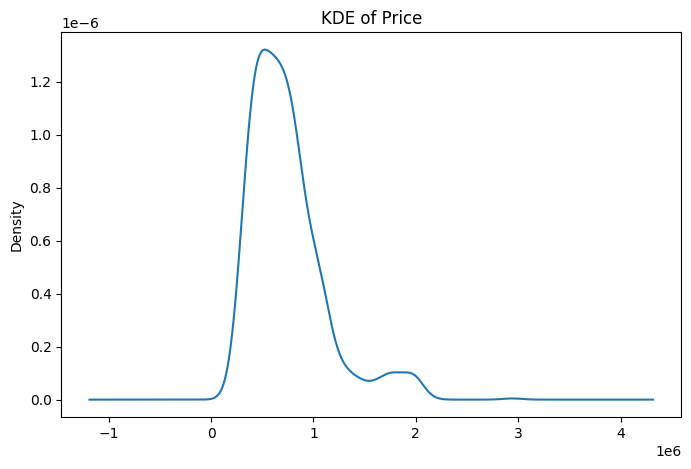

In [50]:
plt.figure(figsize=(8,5))
df["Price"].plot(kind="kde")
plt.title("KDE of Price")
plt.show()

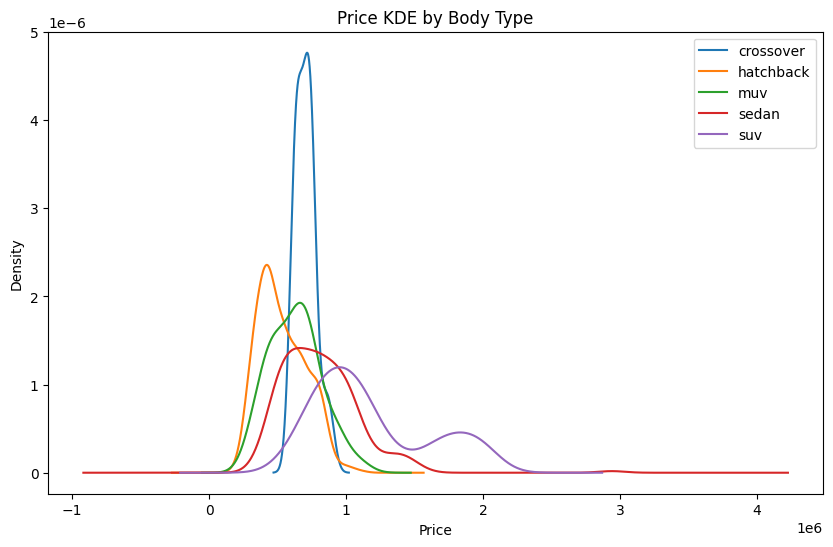

In [51]:
plt.figure(figsize=(10,6))

for b in sorted(df["Body_Type"].unique()):
    df.loc[df["Body_Type"]==b, "Price"].plot(kind="kde", label=b)

plt.legend()
plt.title("Price KDE by Body Type")
plt.xlabel("Price")
plt.show()

QUESTION 2

In [52]:
model_q3_2 = smf.ols(
    "Price ~ Seating_Capacity",
    data=df
).fit()

print(model_q3_2.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.005
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     5.075
Date:                Sun, 22 Mar 2026   Prob (F-statistic):             0.0245
Time:                        10:47:22   Log-Likelihood:                -13888.
No. Observations:                 976   AIC:                         2.778e+04
Df Residuals:                     974   BIC:                         2.779e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          4.39e+05   1.35e+05  

In [53]:
print("Slope:", model_q3_2.params["Seating_Capacity"])

Slope: 59267.99803672188


In [54]:
model_q3_2_cat = smf.ols(
    "Price ~ C(Seating_Capacity)",
    data=df
).fit()

print(model_q3_2_cat.summary())

                            OLS Regression Results                            
Dep. Variable:                  Price   R-squared:                       0.022
Model:                            OLS   Adj. R-squared:                  0.018
Method:                 Least Squares   F-statistic:                     5.397
Date:                Sun, 22 Mar 2026   Prob (F-statistic):           0.000267
Time:                        10:47:37   Log-Likelihood:                -13880.
No. Observations:                 976   AIC:                         2.777e+04
Df Residuals:                     971   BIC:                         2.779e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
Intercept               

QUESTION 3

In [55]:
df["Age"] = df["Make_Year"].max() - df["Make_Year"]

df.head()

,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price,Age
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000,5
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000,6
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000,3
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000,5
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000,5


In [57]:
X = df[["Age"]]
y = df["Price"]

kf = KFold(n_splits=10, shuffle=True, random_state=1)

degrees = range(1,8)
rmse_scores = []

In [60]:
for d in degrees:
    
    model = Pipeline([
        ("poly", PolynomialFeatures(degree=d, include_bias=False)),
        ("reg", LinearRegression())
    ])
    
    mse = -cross_val_score(
        model,
        X,
        y,
        cv=kf,
        scoring="neg_mean_squared_error"
    )
    
    rmse = np.sqrt(mse.mean())
    rmse_scores.append(rmse)

In [61]:
cv_results = pd.DataFrame({
    "degree": degrees,
    "rmse": rmse_scores
})

print(cv_results)

   degree           rmse
0       1  312643.183216
1       2  312754.407726
2       3  311936.013125
3       4  311103.496394
4       5  309542.070599
5       6  309713.727793
6       7  308659.885174


In [62]:
best_degree = cv_results.loc[cv_results["rmse"].idxmin(), "degree"]
print("Best degree:", best_degree)

Best degree: 7


In [63]:
best_model = Pipeline([
    ("poly", PolynomialFeatures(degree=best_degree, include_bias=False)),
    ("reg", LinearRegression())
])

best_model.fit(X,y)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('poly', ...), ('reg', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",np.int64(7)
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06


QUESTION 4

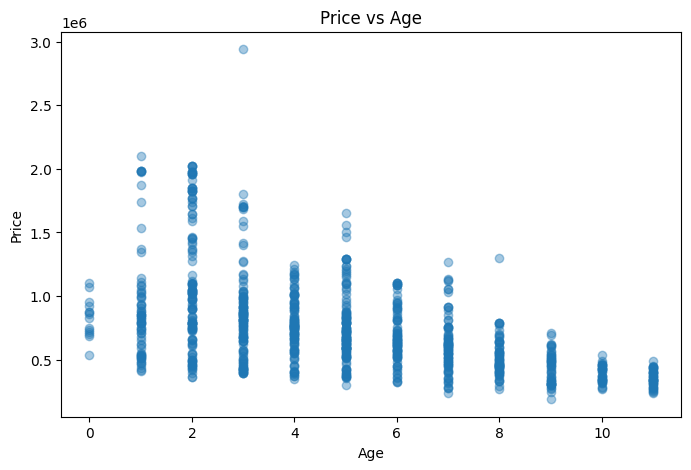

In [64]:
plt.figure(figsize=(8,5))
plt.scatter(df["Age"], df["Price"], alpha=.4)
plt.xlabel("Age")
plt.ylabel("Price")
plt.title("Price vs Age")
plt.show()

In [65]:
age_grid = np.linspace(df["Age"].min(), df["Age"].max(), 200)
age_grid_df = pd.DataFrame({"Age": age_grid})

pred = best_model.predict(age_grid_df)

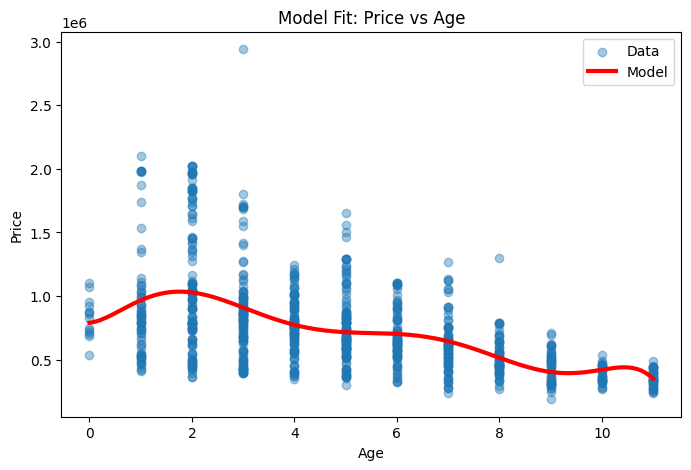

In [66]:
plt.figure(figsize=(8,5))

plt.scatter(df["Age"], df["Price"], alpha=.4, label="Data")

plt.plot(age_grid, pred, color="red", linewidth=3, label="Model")

plt.xlabel("Age")
plt.ylabel("Price")
plt.legend()
plt.title("Model Fit: Price vs Age")

plt.show()

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect (ATE). What is the ATE on three-year survival for heart transplant interventions?
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to the numbers you computed in part 1. 
3. Regress `y` on transplant and age. How does the coefficient on transplant change when you control for age?What do the intercept and slope represent? Plot the predicted probability of survival by age, and add a dashed horizontal line for the ATE from part 1. For what ages is the ATE over- or under-estimating the impact of a transplant?
4. Now, include `transplant`, `age`, and `transplant * age` as controls. Repeat your analysis from part 3. How does allowing age and transplant to interact change your predictions? What pattern do you notice?
5. Use 10-fold cross validation to evaluate the predictive accuracy of these models. 
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


In [67]:
df = pd.read_csv("./data/heart_hw.csv")

df.head()

,Unnamed: 0,age,transplant,y
0,1,53,control,0
1,2,43,control,0
2,3,52,control,0
3,4,52,control,0
4,5,54,control,0


In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [69]:
print(df.columns)
print(df["transplant"].value_counts())

Index(['Unnamed: 0', 'age', 'transplant', 'y'], dtype='str')
transplant
treatment    69
control      34
Name: count, dtype: int64


QUESTION 1

In [70]:
survival_by_group = df.groupby("transplant")["y"].mean()
print(survival_by_group)

transplant
control      0.117647
treatment    0.347826
Name: y, dtype: float64


In [71]:
control_survival = survival_by_group["control"]
treatment_survival = survival_by_group["treatment"]
ate = treatment_survival - control_survival

print("Control survival proportion:", control_survival)
print("Treatment survival proportion:", treatment_survival)
print("ATE (treatment - control):", ate)

Control survival proportion: 0.11764705882352941
Treatment survival proportion: 0.34782608695652173
ATE (treatment - control): 0.23017902813299232


QUESTION 2

In [72]:
model_q4_2 = smf.ols("y ~ C(transplant)", data=df).fit()
print(model_q4_2.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.050
Method:                 Least Squares   F-statistic:                     6.354
Date:                Sun, 22 Mar 2026   Prob (F-statistic):             0.0133
Time:                        10:54:20   Log-Likelihood:                -59.591
No. Observations:                 103   AIC:                             123.2
Df Residuals:                     101   BIC:                             128.5
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

In [73]:
print(model_q4_2.params)

Intercept                     0.117647
C(transplant)[T.treatment]    0.230179
dtype: float64


QUESTION 3

In [74]:
model_q4_3 = smf.ols("y ~ C(transplant) + age", data=df).fit()
print(model_q4_3.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.147
Model:                            OLS   Adj. R-squared:                  0.130
Method:                 Least Squares   F-statistic:                     8.602
Date:                Sun, 22 Mar 2026   Prob (F-statistic):           0.000357
Time:                        10:55:00   Log-Likelihood:                -54.558
No. Observations:                 103   AIC:                             115.1
Df Residuals:                     100   BIC:                             123.0
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

In [75]:
print(model_q4_3.params)

Intercept                     0.701957
C(transplant)[T.treatment]    0.264702
age                          -0.013607
dtype: float64


In [76]:
age_grid = np.linspace(df["age"].min(), df["age"].max(), 200)

pred_df_q4_3 = pd.DataFrame({
    "age": np.concatenate([age_grid, age_grid]),
    "transplant": ["control"] * len(age_grid) + ["treatment"] * len(age_grid)
})

pred_df_q4_3["pred_y"] = model_q4_3.predict(pred_df_q4_3)
pred_df_q4_3.head()

,age,transplant,pred_y
0,8.000000,control,0.593099
1,8.281407,control,0.589270
2,8.562814,control,0.585441
3,8.844221,control,0.581612
4,9.125628,control,0.577783


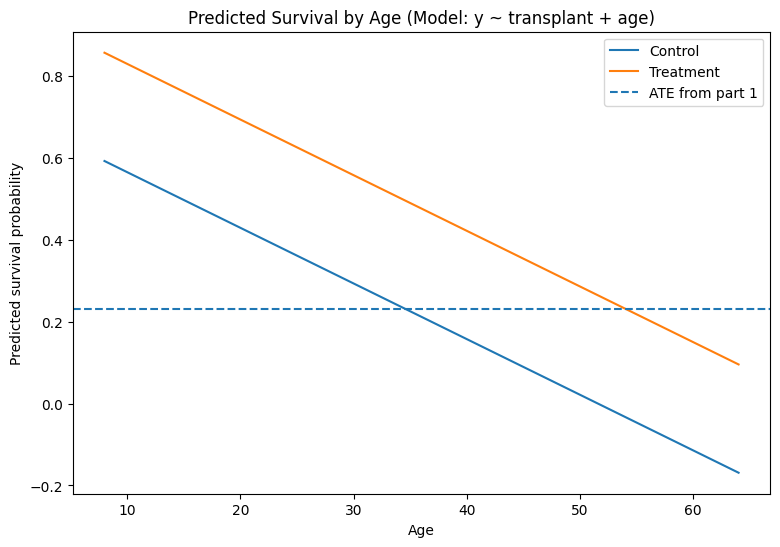

In [77]:
plt.figure(figsize=(9,6))

control_df = pred_df_q4_3[pred_df_q4_3["transplant"] == "control"]
treatment_df = pred_df_q4_3[pred_df_q4_3["transplant"] == "treatment"]

plt.plot(control_df["age"], control_df["pred_y"], label="Control")
plt.plot(treatment_df["age"], treatment_df["pred_y"], label="Treatment")

plt.axhline(ate, linestyle="--", label="ATE from part 1")

plt.xlabel("Age")
plt.ylabel("Predicted survival probability")
plt.title("Predicted Survival by Age (Model: y ~ transplant + age)")
plt.legend()
plt.show()

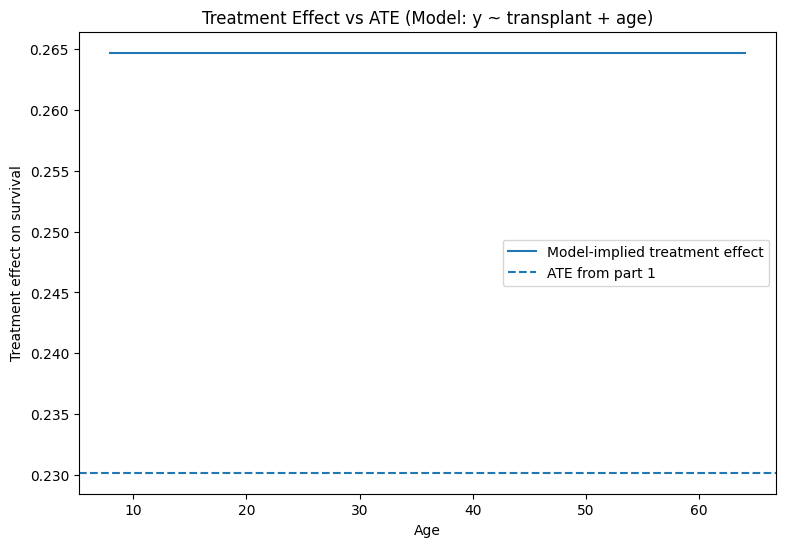

In [78]:
pred_effect_q4_3 = treatment_df["pred_y"].values - control_df["pred_y"].values

plt.figure(figsize=(9,6))
plt.plot(age_grid, pred_effect_q4_3, label="Model-implied treatment effect")
plt.axhline(ate, linestyle="--", label="ATE from part 1")

plt.xlabel("Age")
plt.ylabel("Treatment effect on survival")
plt.title("Treatment Effect vs ATE (Model: y ~ transplant + age)")
plt.legend()
plt.show()

In [79]:
treatment_coef_q4_3 = model_q4_3.params["C(transplant)[T.treatment]"]

print("ATE from part 1:", ate)
print("Treatment coefficient in model q4.3:", treatment_coef_q4_3)
print("Difference:", treatment_coef_q4_3 - ate)

ATE from part 1: 0.23017902813299232
Treatment coefficient in model q4.3: 0.2647016865036752
Difference: 0.034522658370682885


QUESTION 4

In [80]:
model_q4_4 = smf.ols("y ~ C(transplant) * age", data=df).fit()
print(model_q4_4.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.172
Model:                            OLS   Adj. R-squared:                  0.147
Method:                 Least Squares   F-statistic:                     6.839
Date:                Sun, 22 Mar 2026   Prob (F-statistic):           0.000310
Time:                        10:56:12   Log-Likelihood:                -53.033
No. Observations:                 103   AIC:                             114.1
Df Residuals:                      99   BIC:                             124.6
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
Intercept   

In [81]:
print(model_q4_4.params)

Intercept                         0.354865
C(transplant)[T.treatment]        0.907751
age                              -0.005524
C(transplant)[T.treatment]:age   -0.014591
dtype: float64


In [82]:
pred_df_q4_4 = pd.DataFrame({
    "age": np.concatenate([age_grid, age_grid]),
    "transplant": ["control"] * len(age_grid) + ["treatment"] * len(age_grid)
})

pred_df_q4_4["pred_y"] = model_q4_4.predict(pred_df_q4_4)
pred_df_q4_4.head()

,age,transplant,pred_y
0,8.000000,control,0.310671
1,8.281407,control,0.309117
2,8.562814,control,0.307562
3,8.844221,control,0.306007
4,9.125628,control,0.304453


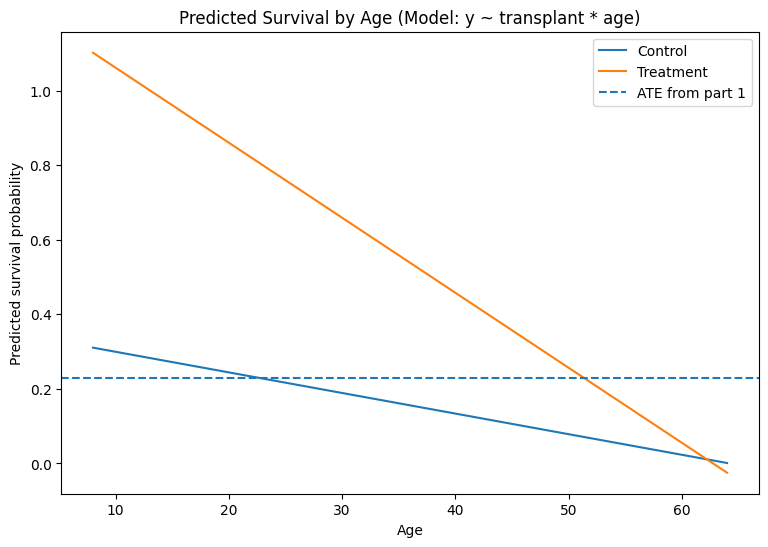

In [83]:
plt.figure(figsize=(9,6))

control_df_4 = pred_df_q4_4[pred_df_q4_4["transplant"] == "control"]
treatment_df_4 = pred_df_q4_4[pred_df_q4_4["transplant"] == "treatment"]

plt.plot(control_df_4["age"], control_df_4["pred_y"], label="Control")
plt.plot(treatment_df_4["age"], treatment_df_4["pred_y"], label="Treatment")

plt.axhline(ate, linestyle="--", label="ATE from part 1")

plt.xlabel("Age")
plt.ylabel("Predicted survival probability")
plt.title("Predicted Survival by Age (Model: y ~ transplant * age)")
plt.legend()
plt.show()

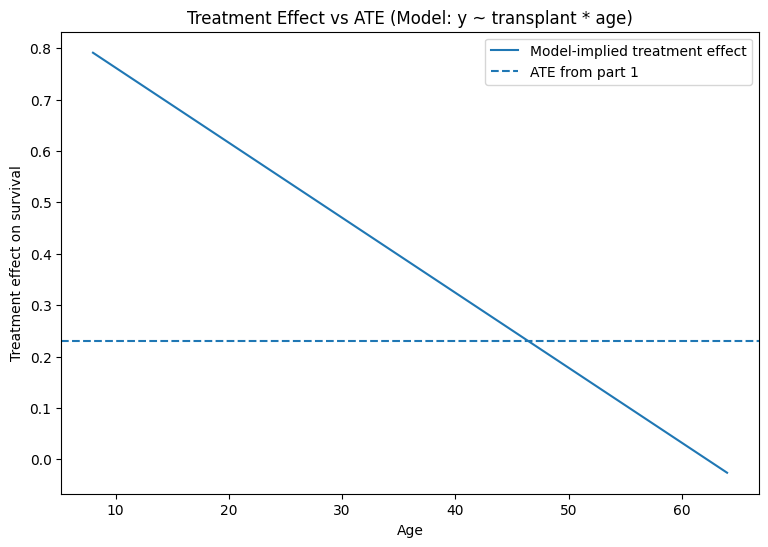

In [84]:
pred_effect_q4_4 = treatment_df_4["pred_y"].values - control_df_4["pred_y"].values

plt.figure(figsize=(9,6))
plt.plot(age_grid, pred_effect_q4_4, label="Model-implied treatment effect")
plt.axhline(ate, linestyle="--", label="ATE from part 1")

plt.xlabel("Age")
plt.ylabel("Treatment effect on survival")
plt.title("Treatment Effect vs ATE (Model: y ~ transplant * age)")
plt.legend()
plt.show()

In [85]:
effect_comparison = pd.DataFrame({
    "age": age_grid,
    "model_effect": pred_effect_q4_4,
    "ate": ate,
    "difference": pred_effect_q4_4 - ate
})

print(effect_comparison.head())

        age  model_effect       ate  difference
0  8.000000      0.791026  0.230179    0.560847
1  8.281407      0.786920  0.230179    0.556741
2  8.562814      0.782814  0.230179    0.552635
3  8.844221      0.778709  0.230179    0.548530
4  9.125628      0.774603  0.230179    0.544424


In [86]:
above_ate = effect_comparison[effect_comparison["model_effect"] > ate]
below_ate = effect_comparison[effect_comparison["model_effect"] < ate]

print("Ages where model-implied treatment effect is above ATE:")
print(above_ate[["age", "model_effect"]].head(10))

print("\nAges where model-implied treatment effect is below ATE:")
print(below_ate[["age", "model_effect"]].head(10))

Ages where model-implied treatment effect is above ATE:
         age  model_effect
0   8.000000      0.791026
1   8.281407      0.786920
2   8.562814      0.782814
3   8.844221      0.778709
4   9.125628      0.774603
5   9.407035      0.770497
6   9.688442      0.766391
7   9.969849      0.762285
8  10.251256      0.758179
9  10.532663      0.754073

Ages where model-implied treatment effect is below ATE:
           age  model_effect
137  46.552764      0.228517
138  46.834171      0.224411
139  47.115578      0.220305
140  47.396985      0.216199
141  47.678392      0.212093
142  47.959799      0.207987
143  48.241206      0.203881
144  48.522613      0.199775
145  48.804020      0.195670
146  49.085427      0.191564


In [87]:
effect_comparison["abs_diff"] = np.abs(effect_comparison["difference"])
crossing_row = effect_comparison.loc[effect_comparison["abs_diff"].idxmin()]

print("Approximate age where model effect is closest to ATE:")
print(crossing_row[["age", "model_effect", "ate"]])

Approximate age where model effect is closest to ATE:
age             46.552764
model_effect     0.228517
ate              0.230179
Name: 137, dtype: float64


QUESTION 5

In [88]:
df["transplant_ind"] = (df["transplant"] == "treatment").astype(int)
df.head()

,Unnamed: 0,age,transplant,y,transplant_ind
0,1,53,control,0,0
1,2,43,control,0,0
2,3,52,control,0,0
3,4,52,control,0,0
4,5,54,control,0,0


In [89]:
df["transplant_age"] = df["transplant_ind"] * df["age"]

In [90]:
y_cv = df["y"]

X1 = df[["transplant_ind"]]
X2 = df[["transplant_ind", "age"]]
X3 = df[["transplant_ind", "age", "transplant_age"]]

In [91]:
kf = KFold(n_splits=10, shuffle=True, random_state=1)

In [92]:
model1 = LinearRegression()
mse1 = -cross_val_score(model1, X1, y_cv, cv=kf, scoring="neg_mean_squared_error")
rmse1 = np.sqrt(mse1)

print("Model 1: y ~ transplant")
print("Mean MSE:", mse1.mean())
print("Mean RMSE:", rmse1.mean())

Model 1: y ~ transplant
Mean MSE: 0.19497249586192153
Mean RMSE: 0.4371241492420901


In [93]:
model2 = LinearRegression()
mse2 = -cross_val_score(model2, X2, y_cv, cv=kf, scoring="neg_mean_squared_error")
rmse2 = np.sqrt(mse2)

print("Model 2: y ~ transplant + age")
print("Mean MSE:", mse2.mean())
print("Mean RMSE:", rmse2.mean())

Model 2: y ~ transplant + age
Mean MSE: 0.17926415954952163
Mean RMSE: 0.42099983660598966


In [94]:
model3 = LinearRegression()
mse3 = -cross_val_score(model3, X3, y_cv, cv=kf, scoring="neg_mean_squared_error")
rmse3 = np.sqrt(mse3)

print("Model 3: y ~ transplant + age + transplant*age")
print("Mean MSE:", mse3.mean())
print("Mean RMSE:", rmse3.mean())

Model 3: y ~ transplant + age + transplant*age
Mean MSE: 0.1788020676251734
Mean RMSE: 0.42010824697341576


In [95]:
cv_results = pd.DataFrame({
    "model": [
        "y ~ transplant",
        "y ~ transplant + age",
        "y ~ transplant + age + transplant*age"
    ],
    "mean_mse": [
        mse1.mean(),
        mse2.mean(),
        mse3.mean()
    ],
    "mean_rmse": [
        rmse1.mean(),
        rmse2.mean(),
        rmse3.mean()
    ]
}).sort_values("mean_rmse")

print(cv_results)

                                   model  mean_mse  mean_rmse
2  y ~ transplant + age + transplant*age  0.178802   0.420108
1                   y ~ transplant + age  0.179264   0.421000
0                         y ~ transplant  0.194972   0.437124


QUESTION 6

One concern with deploying this model to prioritize transplant access is that it may reflect selection bias rather than causal effects. The patients who receive a transplant would likely differ systematically from those who do not, possibly being healthier, younger, etc. Thus, the model might attribute the difference in survival to the transplant, which is partially due to other health factors not included. There is a fairness issue as well: the model using age as a predictor might not be fair to older patients, since its predictions might be applied mechanically. The model is predictive, not causal, so a good predictive model does not necessarily mean the patient will actually benefit from the transplant. The allocation of a transplant is a high-stakes issue, and decisions should not be made solely on the basis of the model.